In [1]:
import numpy as np
import torch
import torch.nn as nn
# from torchsummary import summary
import pickle
import matplotlib.pyplot as plt

from tqdm.auto import tqdm, trange
import os
import sys
from pathlib import Path
from datetime import datetime
import random
from random import randint

import gc

import time

/Users/litvan007/Voice-commands-recognition/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data gaining

In [216]:
def sound_show(inp, title=None, marks_true=None, marks_pred=None, sample_rate=16000):
    time = np.linspace(0., inp.size / sample_rate, inp.size)
    height = 1.5 * np.max(np.abs(inp))
    plt.figure(figsize=(16, 6))
    signal_line, = plt.plot(time, inp, label='Signal')
    plt.title(title)

    handles = [signal_line]
    labels = ['Signal']

    ax = plt.gca()

    if marks_pred is not None:
        marks_pred = torch.squeeze(marks_pred.detach()).cpu().numpy()
        words_grid_pred = find_words_edges(marks_pred, sample_rate)
        for edges in words_grid_pred:
            span = ax.axvspan(edges[0], edges[1], color='green', alpha=0.2)
        handles.append(span)
        labels.append('Predicted speech')

    if marks_true is not None:
        marks_true = torch.squeeze(marks_true).cpu().numpy()
        words_grid_true = find_words_edges(marks_true, sample_rate)
        for edges in words_grid_true:
            span = ax.axvspan(edges[0], edges[1], color='red', alpha=0.3, linestyle='--')
        handles.append(span)
        labels.append('True speech')

    plt.legend(handles, labels)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

def find_words_edges(marks, sample_rate=16000):
    lst = []
    in_speech = False
    temp = []
    for i, m in enumerate(marks):
        if m == 1 and not in_speech:
            temp = [i / sample_rate]
            in_speech = True
        elif m == 0 and in_speech:
            temp.append(i / sample_rate)
            lst.append(temp)
            in_speech = False
    if in_speech:
        temp.append(len(marks) / sample_rate)
        lst.append(temp)
    return np.array(lst)


In [238]:

def sound_show_numpy(inp, title=None, marks_true=None, marks_pred=None, sample_rate=16000,
                      threshold=0.5, merge_segments=False, merge_gap=0.1, valid_frames=None):
    """
    Отображает аудиосигнал с разметками речи.

    Параметры:
      inp: numpy-массив аудиосигнала.
      title: заголовок графика.
      marks_true: numpy-массив сырых значений (после sigmoid) истинной разметки.
      marks_pred: numpy-массив сырых значений (после sigmoid) предсказанной разметки.
      sample_rate: частота дискретизации аудио (по умолчанию 16000).
      threshold: порог для бинаризации разметки.
      merge_segments: если True, объединяет интервалы, разделённые промежутком менее merge_gap.
      merge_gap: максимальный промежуток (в секундах) между сегментами для слияния.
      valid_frames: число валидных (непаддингованных) фреймов в признаках.
                   Если задано, границы сегментов рассчитываются с использованием marks[:valid_frames],
                   а если сегмент активен и до конца valid_frames не завершён, его конец заменяется на valid_frames/sample_rate.
    """
    full_duration = inp.size / sample_rate  # полная длительность аудио

    time = np.linspace(0., full_duration, inp.size)
    plt.figure(figsize=(16, 6))
    signal_line, = plt.plot(time, inp, label='Signal')
    if title is not None:
        plt.title(title)

    handles = [signal_line]
    labels = ['Signal']
    ax = plt.gca()

    # Обработка предсказанной разметки
    if marks_pred is not None:
        marks_pred = np.squeeze(marks_pred)
        # Бинаризуем по порогу
        marks_pred_bin = (marks_pred >= threshold).astype(np.int32)
        words_grid_pred = find_words_edges(marks_pred_bin, sample_rate,
                                           merge_segments=merge_segments, merge_gap=merge_gap,
                                           valid_frames=valid_frames, full_duration=full_duration)
        for edges in words_grid_pred:
            span_pred = ax.axvspan(edges[0], edges[1], color='green', alpha=0.2)
            handles.append(span_pred)
            labels.append('Predicted speech')

    # Обработка истинной разметки
    if marks_true is not None:
        marks_true = np.squeeze(marks_true)
        marks_true_bin = (marks_true >= threshold).astype(np.int32)
        words_grid_true = find_words_edges(marks_true_bin, sample_rate,
                                           merge_segments=merge_segments, merge_gap=merge_gap,
                                           valid_frames=valid_frames, full_duration=full_duration)
        for edges in words_grid_true:
            span_true = ax.axvspan(edges[0], edges[1], color='red', alpha=0.3, linestyle='--')
            handles.append(span_true)
            labels.append('True speech')

    plt.legend(handles, labels)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()


def find_words_edges(marks, sample_rate=16000, merge_segments=False, merge_gap=0.1,
                     valid_frames=None, full_duration=None):
    """
    Находит интервалы, где речь (значение 1) начинается и заканчивается.

    Аргументы:
      marks: бинарный numpy-массив (0 или 1).
      sample_rate: частота дискретизации (для пересчёта индексов в секунды).
      merge_segments: если True, объединяет соседние сегменты, если промежуток между ними ≤ merge_gap.
      merge_gap: порог для слияния сегментов, в секундах.
      valid_frames: число валидных фреймов (без паддинга). Если задано, итерация идёт только по marks[:valid_frames].
      full_duration: полная длительность аудио (в секундах). Не используется в данном варианте.
      
    Возвращает:
      numpy-массив с парами [начало, конец] для каждого сегмента речи.
      Если сегмент начался в пределах valid_frames, но его завершение выходит за valid_frames, то конец сегмента
      заменяется на valid_frames/sample_rate.
    """
    # Если valid_frames не задан или больше длины marks, используем всю длину marks
    if valid_frames is None or valid_frames > len(marks):
        valid_frames = len(marks)
    
    segments = []
    in_speech = False
    temp = []
    
    # Итерация только по валидным фреймам
    for i, m in enumerate(marks[:valid_frames]):
        if m == 1 and not in_speech:
            temp = [i / sample_rate]
            in_speech = True
        elif m == 0 and in_speech:
            temp.append(i / sample_rate)
            segments.append(temp)
            in_speech = False
    
    # Если сегмент активен и до конца valid_frames не завершён,
    # заменяем его правую границу на valid_frames/sample_rate
    if in_speech:
        temp.append(valid_frames / sample_rate)
        segments.append(temp)
    
    # При объединении сегментов, если требуется
    if merge_segments and len(segments) > 1:
        merged = [segments[0]]
        for current in segments[1:]:
            if current[0] - merged[-1][1] <= merge_gap:
                merged[-1][1] = current[1]
            else:
                merged.append(current)
        segments = merged

    return np.array(segments)


In [3]:
import torch
from torch.utils.data import Dataset
from glob import glob
import os

class PrecomputedDataset(Dataset):
    def __init__(self, data_dir):
        self.files = glob(os.path.join(data_dir, '*.pt'))

    def __getitem__(self, index):
        sample = torch.load(self.files[index])
        return sample['xname'], sample['X'], sample['y'], sample['signal']

    def __len__(self):
        return len(self.files)

# Использование:
dataset_precomputed = PrecomputedDataset('data_preprocessed/train_samples')


**Emobase dataset**

/tmp/ipykernel_46580/476797563.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sample = torch.load(self.files[index])


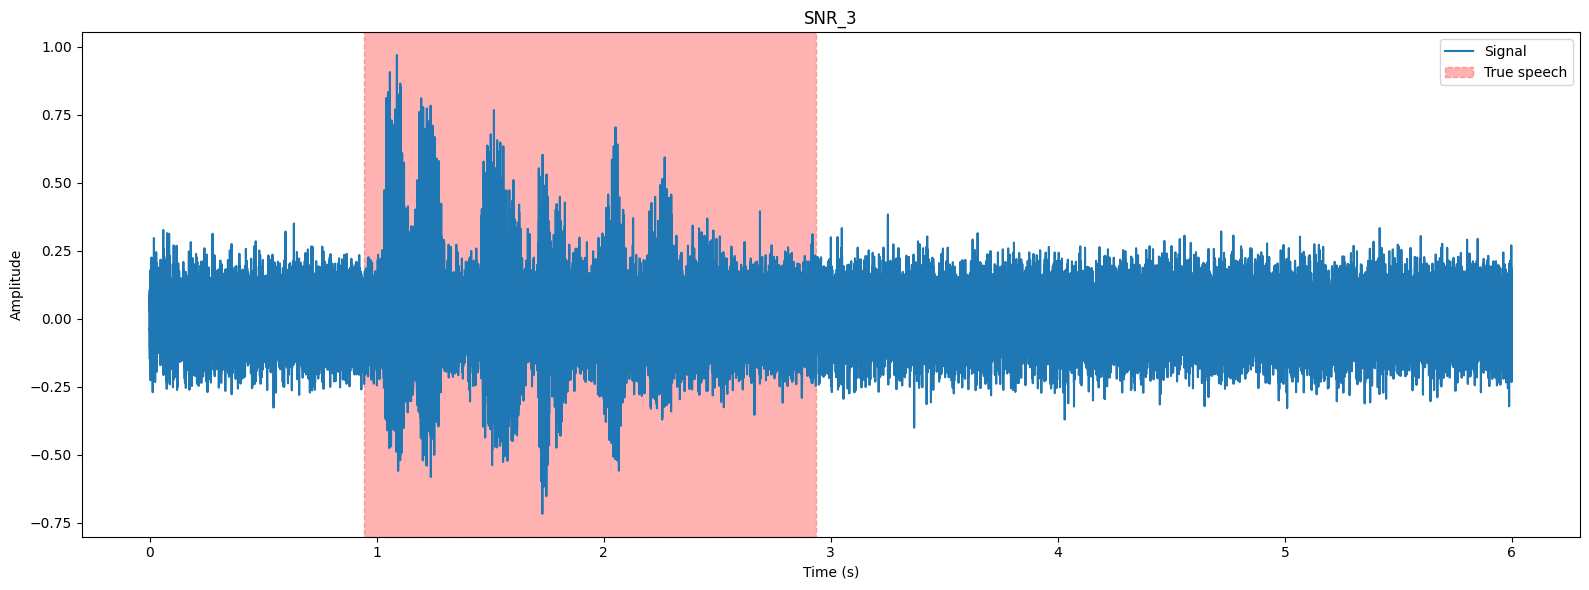

In [17]:
from torch.utils.data import DataLoader

data_set_emobase = {
            'train': PrecomputedDataset('data_preprocessed/train_samples'),
            'valid': PrecomputedDataset('data_preprocessed/valid_samples'),
            'test': PrecomputedDataset('data_preprocessed/test_samples')
           }

batch_size = 512
loaders_emobase = {
            'train': torch.utils.data.DataLoader(data_set_emobase['train'], batch_size=batch_size, shuffle=True),
            'valid': torch.utils.data.DataLoader(data_set_emobase['valid'], batch_size=batch_size, shuffle=True),
            'test': torch.utils.data.DataLoader(data_set_emobase['test'], batch_size=1, shuffle=False)
          }

dataset_sizes = {x: len(data_set_emobase[x]) for x in ['train', 'valid']}
xname, X, y, signal = data_set_emobase['train'][81]
sound_show(signal, title=f'SNR_{xname.split("_SNR_")[1]}', marks_true=y, marks_pred=None)

# Models

**New model with emobase based on the Article**

In [4]:
class Conv_emobase(nn.Module):
    def __init__(self):
        super().__init__()
        self.dropout = nn.Dropout(p=0.7)
        self.activation = nn.LeakyReLU(negative_slope=0.2)

        # convolution
        self.conv1 = nn.Conv2d(in_channels=1,
                      out_channels=64,
                      kernel_size=(5, 20),
                      stride=(2, 6),
                      padding=(2, 10))
        self.conv1_batch_norm = nn.BatchNorm2d(num_features=64)

        self.conv2 = nn.Conv2d(in_channels=64,
                      out_channels=128,
                      kernel_size=(3, 3),
                      stride=(2, 2),
                      padding=(1, 1))
        self.conv2_batch_norm = nn.BatchNorm2d(num_features=128)

        self.conv3 = nn.Conv2d(in_channels=128,
                      out_channels=256,
                      kernel_size=(6, 13),
                      stride=(2, 2),
                      padding=(0, 1))
        self.conv3_batch_norm = nn.BatchNorm2d(num_features=256)

        # deconvolution
        self.deconv1 = nn.ConvTranspose1d(in_channels=256,
                               out_channels=128,
                               kernel_size=101,
                               stride=10,
                               padding=50,
                               output_padding=9)
        self.deconv1_batch_norm = nn.BatchNorm1d(num_features=128)

        self.deconv2 = nn.ConvTranspose1d(in_channels=128,
                               out_channels=64,
                               kernel_size=101,
                               stride=12,
                               padding=50,
                               output_padding=11)
        self.deconv2_batch_norm = nn.BatchNorm1d(num_features=64)

        self.deconv3 = nn.ConvTranspose1d(
            in_channels=64,
            out_channels=1,
            kernel_size=101,
            stride=40,               # было 20
            padding=50,
            output_padding=39        # было 19
        )

    def forward(self, x):
        # Convolution
        x = self.conv1_batch_norm(self.activation(self.dropout(self.conv1(x))))
        x = self.conv2_batch_norm(self.activation(self.dropout(self.conv2(x))))
        x = self.conv3_batch_norm(self.activation(self.dropout(self.conv3(x))))

        # Deconvolution
        x = torch.squeeze(x, -2)
        x = self.deconv1_batch_norm(self.activation(self.dropout(self.deconv1(x))))
        x = self.deconv2_batch_norm(self.activation(self.dropout(self.deconv2(x))))

        return self.deconv3(x)

# Model prepare

In [5]:
device = torch.device('cpu') if torch.cpu.is_available() else torch.device('cpu')
device

AttributeError: module 'torch.cpu' has no attribute 'is_available'

In [6]:
def init_weights(m):
    if type(m) in (nn.Conv1d, nn.Conv2d, nn.ConvTranspose1d):
        nn.init.kaiming_uniform_(m.weight, a=0.2, nonlinearity='leaky_relu')
    else:
        print('Not setting weights for type {}'.format(type(m)))
        

In [7]:
def save(path, loss, epoch, model, optim, scheduler, train_losses, valid_losses, train_metrics, valid_metrics):
    torch.save({
        'loss': loss,
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optim.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_loss_epochs': train_losses,
        'valid_loss_epochs': valid_losses,
        'train_metrics': train_metrics,
        'valid_metrics': valid_metrics
    }, path)

In [8]:
def binary_acc(y_pred, y_test):
    correct_results_sum = (y_pred == y_test).sum().float()
    print(torch.unique(y_pred))
    acc = correct_results_sum/(y_test.shape[0]*y_test.shape[2])
    # acc = torch.round(acc * 100)
    
    return acc

In [9]:
epochs = 13

In [10]:
def train(model, optim, loss, scheduler, dataloader):
    total = 0
    correct = 0
    losses = []

    model.train()
    for i, batch in enumerate(tqdm(dataloader)):
        xname, X, marks, _ = batch
        X, marks = X.cpu(), marks.cpu()
        optim.zero_grad()
        out = model(X)
        loss_batch = loss(out, marks)
        losses.append(loss_batch.item())
        loss_batch.backward()
        optim.step()
        scheduler.step()

        prediction = torch.round(torch.sigmoid(out)).type(torch.int8)
        marks = marks.type(torch.int8)

    return np.mean(losses), {'Accuracy': binary_acc(prediction, marks)}

In [11]:
def valid(model, loss, dataloader):
    total = 0
    correct = 0
    losses = []

    model.eval()
    with torch.no_grad():
        for i, batch in enumerate(tqdm(dataloader)):
            xname, X, marks, _ = batch
            X, marks = X.cpu(), marks.cpu()
            out = model(X)
            loss_batch = loss(out, marks)
            losses.append(loss_batch.item())

            prediction = torch.round(torch.sigmoid(out)).type(torch.int8)
            marks = marks.type(torch.int8)

    return np.mean(losses), {'Accuracy': binary_acc(prediction, marks)}

In [12]:
def init_model(path=None, only_inferencse=False):
    max_lr = 0.05
    div_factor = 250
    weight_decay = 0.0005

    loss = nn.BCEWithLogitsLoss(pos_weight=torch.ones(96000, dtype=torch.float16).cpu() * 3).cpu()

    model = Conv_emobase().cpu()
    if not only_inferencse:
        optim = torch.optim.AdamW(model.parameters(), lr=max_lr / div_factor,
                                    weight_decay=weight_decay, amsgrad=True)
        scheduler = torch.optim.lr_scheduler.OneCycleLR(optim, max_lr=max_lr,
                                steps_per_epoch=len(loaders_emobase['train']),
                                epochs=epochs, div_factor=div_factor)

    if path is None:    
        model.apply(init_weights)

    epoch = 0
    train_losses = []
    valid_losses = []
    train_metrics = {
        'Accuracy': []
    }
    valid_metrics = {
        'Accuracy': []
    }

    if path is not None:
        checkpoint = torch.load(path, map_location=torch.device('cpu'))
        
        # print(checkpoint['optimizer_state_dict'])

        model.load_state_dict(checkpoint['model_state_dict'])
        train_losses = checkpoint['train_loss_epochs']
        valid_losses = checkpoint['valid_loss_epochs']
        epoch = checkpoint['epoch'] + 1
        print(epoch, valid_losses)
        loss = checkpoint['loss']
        train_metrics = checkpoint['train_metrics']
        valid_metrics = checkpoint['valid_metrics']
    
    if not only_inferencse:
        optim.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

        return model, loss, optim, scheduler, epoch, train_losses, valid_losses, train_metrics, valid_metrics
    
    else:
        return model, loss, epoch, train_losses, valid_losses, train_metrics, valid_metrics

# Model emobase training

In [27]:
savedir = './models'
torch.cpu.empty_cache()
gc.collect()

model, loss, optim, scheduler, epoch, train_losses, valid_losses, train_metrics, valid_metrics = init_model(path=None)
# print(scheduler, epoch, train_losses, valid_losses, train_metrics, valid_metrics)
model_name = 'emobase'
best_path = None
best_acc = 0
bect_epoch = 0

for i in range(epoch, epochs):
    train_loss, metrics = train(model, optim, loss, scheduler, loaders_emobase['train'])
    
    train_losses.append(train_loss)
    train_acc = metrics['Accuracy'].item()
    train_metrics['Accuracy'].append(train_acc)

    valid_loss, metrics = valid(model, loss, loaders_emobase['valid'])
    valid_acc = metrics['Accuracy'].item()
    valid_metrics['Accuracy'].append(valid_acc)

    print(f'{i} epoch')
    print(valid_loss)
    if i == 0 or valid_loss < np.min(valid_losses) or True:
        best_path = os.path.join(savedir, datetime.now().strftime('{0}_{1}_{2:.3f}_%Y-%m-%d_%H'.format(model_name, i, valid_loss)))
        print(best_path)
        valid_losses.append(valid_loss)
        save(best_path, loss, i, model, optim, scheduler, train_losses, valid_losses, train_metrics, valid_metrics)

    else:
        valid_losses.append(valid_loss)


Not setting weights for type <class 'torch.nn.modules.dropout.Dropout'>
Not setting weights for type <class 'torch.nn.modules.activation.LeakyReLU'>
Not setting weights for type <class 'torch.nn.modules.batchnorm.BatchNorm2d'>
Not setting weights for type <class 'torch.nn.modules.batchnorm.BatchNorm2d'>
Not setting weights for type <class 'torch.nn.modules.batchnorm.BatchNorm2d'>
Not setting weights for type <class 'torch.nn.modules.batchnorm.BatchNorm1d'>
Not setting weights for type <class 'torch.nn.modules.batchnorm.BatchNorm1d'>
Not setting weights for type <class '__main__.Conv_emobase'>


/tmp/ipykernel_46580/476797563.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sample = torch.load(self.files[index])
100%|██████████| 153/153 [03:45<00:00,  1.48s/it]


tensor([0, 1], device='cuda:0', dtype=torch.int8)


100%|██████████| 17/17 [00:24<00:00,  1.47s/it]


tensor([0, 1], device='cuda:0', dtype=torch.int8)
0 epoch
0.22177133139441996
./models/emobase_0_0.222_2025-04-10_09


...

tensor([0, 1], device='cuda:0', dtype=torch.int8)
11 epoch
0.15534170760827906
./models/emobase_11_0.155_2025-04-10_10


100%|██████████| 153/153 [03:47<00:00,  1.49s/it]


tensor([0, 1], device='cuda:0', dtype=torch.int8)


100%|██████████| 17/17 [00:24<00:00,  1.47s/it]

tensor([0, 1], device='cuda:0', dtype=torch.int8)
12 epoch
0.15042833545628717
./models/emobase_12_0.150_2025-04-10_10


# Sanity check

In [29]:
from sklearn.metrics import classification_report
import sys

In [30]:
def metrics_test_compute(model, loader):
    torch.cpu.empty_cache()
    gc.collect()

    test_metrics = {
            'acc': np.array([]),
            'prec': np.array([]),
            'rec': np.array([]),
            'F1': np.array([])
    }

    model.eval()
    with torch.no_grad():
        for i, batch in enumerate(tqdm(loader)):
            xname, X, marks, _ = batch
            X, marks = X.cpu(), marks.cpu()
            out = model(X)

            marks = marks.squeeze().type(torch.int8)
            prediction = torch.round(torch.sigmoid(out)).squeeze().type(torch.int8)

            temp_dict = classification_report(prediction.cpu().numpy(), marks.cpu().numpy(), output_dict=True)['1']
            temp_acc = classification_report(prediction.cpu().numpy(), marks.cpu().numpy(), output_dict=True)['accuracy']
            test_metrics['acc'] = np.append(test_metrics['acc'], temp_acc)
            test_metrics['prec'] = np.append(test_metrics['prec'], temp_dict['precision'])
            test_metrics['rec'] = np.append(test_metrics['rec'], temp_dict['recall'])
            test_metrics['F1'] = np.append(test_metrics['F1'], temp_dict['f1-score'])


    metrics = {'Accuracy': np.mean(test_metrics['acc']), 'Precision': np.mean(test_metrics['prec']), 'Recall': np.mean(test_metrics['rec']), 'F1': np.mean(test_metrics['F1'])}
    return metrics

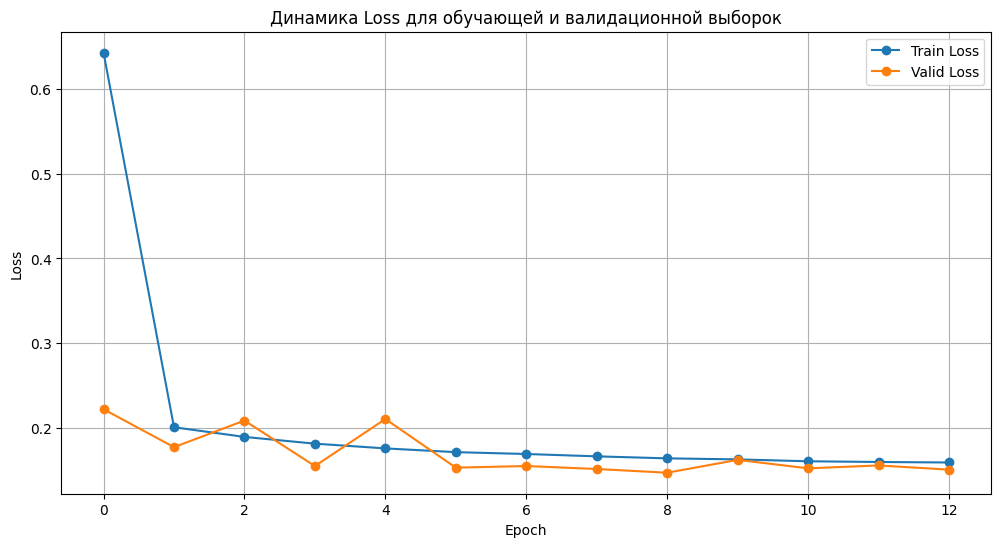

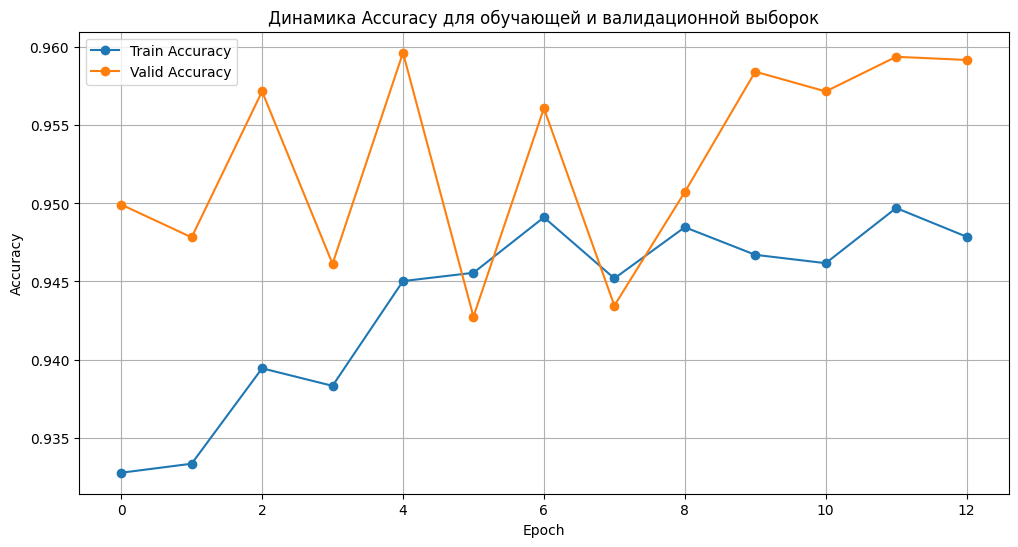

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Предполагается, что train_losses, valid_losses, train_metrics['Accuracy'] и valid_metrics['Accuracy']
# заполнены в процессе обучения, а epoch — начальный номер эпохи обучения (например, 0 или другая точка)

# Создаём массив с номерами эпох на основе длины списков потерь (если обучение началось с определённой эпохи)
epochs_range = np.arange(epoch, epoch + len(train_losses))

# График потерь
plt.figure(figsize=(12, 6))
plt.plot(epochs_range, train_losses, label='Train Loss', marker='o')
plt.plot(epochs_range, valid_losses, label='Valid Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Динамика Loss для обучающей и валидационной выборок')
plt.legend()
plt.grid(True)
plt.show()

# График точности
plt.figure(figsize=(12, 6))
plt.plot(epochs_range, train_metrics['Accuracy'], label='Train Accuracy', marker='o')
plt.plot(epochs_range, valid_metrics['Accuracy'], label='Valid Accuracy', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Динамика Accuracy для обучающей и валидационной выборок')
plt.legend()
plt.grid(True)
plt.show()


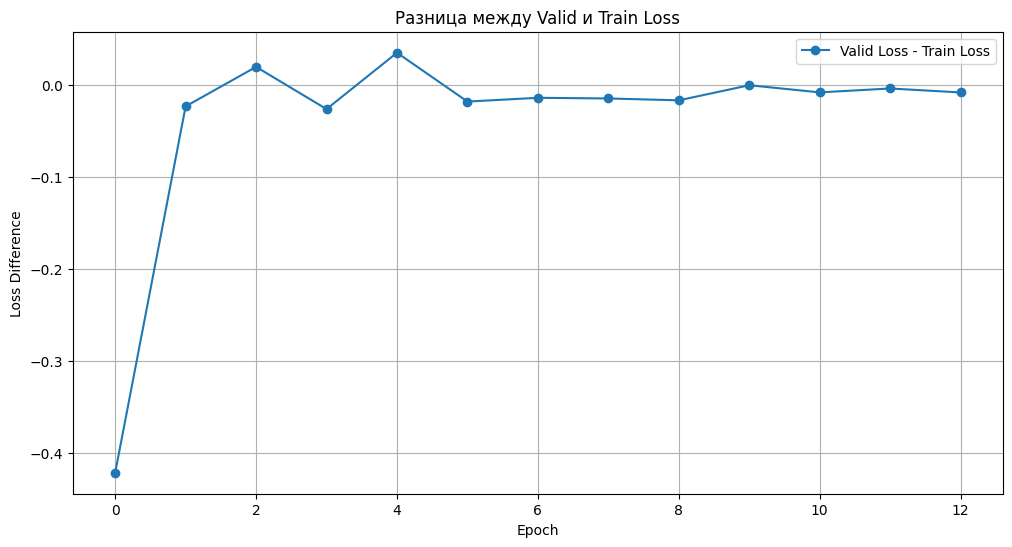

In [36]:
plt.figure(figsize=(12, 6))
plt.plot(epochs_range, np.array(valid_losses) - np.array(train_losses), label='Valid Loss - Train Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss Difference')
plt.title('Разница между Valid и Train Loss')
plt.legend()
plt.grid(True)
plt.show()


In [35]:
best_epoch = epochs_range[np.argmax(train_metrics['Accuracy'])]
best_valid_acc = np.max(valid_metrics['Accuracy'])
print(f"Лучший результат по валидационной точности: {best_valid_acc:.2f} на эпохе {best_epoch}")


Лучший результат по валидационной точности: 0.96 на эпохе 11


## Emobase

In [31]:
model_emobase = Conv_emobase().cpu()
checkpoint = torch.load('./models/emobase_12_0.150_2025-04-10_10')
model_emobase.load_state_dict(checkpoint['model_state_dict'])

/tmp/ipykernel_46580/4275003063.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('./models/emobase_12_0.150_2025-04-10_10')


<All keys matched successfully>

### Common Metrics

In [33]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

metrics_test_compute(model_emobase, loaders_emobase['test'])

100%|██████████| 10377/10377 [07:02<00:00, 24.54it/s]


{'Accuracy': np.float64(0.9578173916273166),
 'Precision': np.float64(0.9773246029651665),
 'Recall': np.float64(0.9362121290416123),
 'F1': np.float64(0.9544795454856799)}

# ONNX Output

In [13]:
model, loss, epoch, train_losses, valid_losses, train_metrics, valid_metrics = init_model(path='./emobase_12_0.150_2025-04-10_10', only_inferencse=True)

13 [0.22177133139441996, 0.17697051781065323, 0.2083933817989686, 0.1546409042442546, 0.21020188752342672, 0.15276737072888544, 0.15466239960754619, 0.1511695542756249, 0.1467675531611723, 0.16194753436481252, 0.15196596086025238, 0.15534170760827906, 0.15042833545628717]


In [14]:
model.eval()  # Перевод модели в режим оценки

# Создание dummy_input с подходящими размерами.
# Здесь укажите реальные размеры H и W, ожидаемые моделью.
dummy_input = torch.randn(1, 1, 26, 598)  # Пример, проверьте, что форма корректна

# Экспорт в ONNX формат
torch.onnx.export(model,
                  dummy_input,
                  "conv_emobase.onnx",
                  export_params=True,                # Сохраняем все параметры модели
                  opset_version=11,                   # Номер версии ONNX opset
                  do_constant_folding=True,           # Оптимизация константных выражений
                  input_names=['input'],              # Имена входных узлов
                  output_names=['output'],            # Имена выходных узлов
                  dynamic_axes={'input': {0: 'batch_size'},    # Поддержка переменного размера батча
                                'output': {0: 'batch_size'}})

================ Diagnostic Run torch.onnx.export version 2.0.1 ================
verbose: False, log level: Level.ERROR
======================= 0 NONE 0 NOTE 0 WARNING 0 ERROR ========================



In [129]:
import onnxruntime as ort
import numpy as np

# Загружаем сохранённую ONNX модель
session = ort.InferenceSession("conv_emobase.onnx")

# Определите dummy_input с нужными размерами.
# Здесь пример с формой [batch, channels, height, width]

# Получаем имя входного узла
input_name = session.get_inputs()[0].name


In [186]:
# import opensmile
# import librosa
# import numpy as np
# import torch

# # Инициализация opensmile
# smile = opensmile.Smile(
#     feature_set=opensmile.FeatureSet.emobase,
#     feature_level=opensmile.FeatureLevel.LowLevelDescriptors,
# )

# # Загрузка аудиосигнала
# signal, sr = librosa.load('./recognized_20250403_211519.wav', sr=16000)
# print("Исходная форма сигнала:", signal.shape)

# # Приводим длину сигнала к 6 секундам (96000 отсчетов)
# desired_length = 96000
# if signal.shape[0] < desired_length:
#     pad_length = desired_length - signal.shape[0]
#     signal = np.pad(signal, (0, pad_length), mode='constant')
# elif signal.shape[0] > desired_length:
#     signal = signal[:desired_length]
# print("Форма сигнала после паддинга/усечения:", signal.shape)

# # Получение признаков с помощью opensmile
# features = smile.process_signal(signal, sr).to_numpy().astype('float32')

# # Если нужна транспонированная версия, как в вашем примере:
# X_tesnor = torch.unsqueeze(torch.transpose(torch.from_numpy(features), 0, 1), 0)
# X_numpy = np.expand_dims(np.expand_dims(features.T, 0), 0)
# # 
# print("X_tesnor.shape:", X_tesnor.shape)
# print("X_numpy.shape:", X_numpy.shape)


In [319]:
import opensmile
import librosa
import numpy as np
import torch

# Инициализация opensmile
smile = opensmile.Smile(
    feature_set=opensmile.FeatureSet.emobase,
    feature_level=opensmile.FeatureLevel.LowLevelDescriptors,
)

# Загрузка аудиосигнала
signal, sr = librosa.load('./recognized_20250403_211611.wav', sr=16000)
# signal, sr = librosa.load('./0a0b3773dcc1cdefe6258892f4c2e87c_SNR_1.wav', sr=16000)
print("Исходная форма сигнала:", signal.shape)

# Приведение сигнала к 6 секундам (96000 отсчетов)
desired_length = 96000
valid_frames = signal.shape[0]
if signal.shape[0] < desired_length:
    pad_length = desired_length - signal.shape[0]
    # Берем первые 5 отсчетов сигнала
    first_five = signal[:1000]
    # Заполняем недостающую часть, выбирая случайным образом из первых 5 отсчетов
    pad_segment = np.random.choice(first_five, size=pad_length, replace=True)
    padded_signal = np.concatenate([signal, pad_segment])

    features = smile.process_signal(padded_signal, sr).to_numpy().astype('float32')

else:
    features = smile.process_signal(signal, sr).to_numpy().astype('float32')

# Сохраним число валидных фреймов (до паддинга)
print("Форма фичей:", features.shape)

# Если нужна транспонированная версия, получаем форму (1, 1, n_features, time)
X_tensor = torch.unsqueeze(torch.transpose(torch.from_numpy(features), 0, 1), 0)
X_numpy = np.expand_dims(np.expand_dims(features.T, 0), 0)

print("X_tensor.shape:", X_tensor.shape)
print("X_numpy.shape:", X_numpy.shape)
print("Валидных фреймов:", valid_frames)


Исходная форма сигнала: (24892,)
Форма фичей: (598, 26)
X_tensor.shape: torch.Size([1, 26, 598])
X_numpy.shape: (1, 1, 26, 598)
Валидных фреймов: 24892


In [320]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [321]:
outputs = session.run(None, {input_name: X_numpy})

# outputs — список выходов модели (если модель имеет один выход, можно взять outputs[0])
print("Результат инференса:", outputs[0])

Результат инференса: [[[ 1.2833894   1.3052148   1.2883781  ... -0.8733935  -0.87466556
   -0.88402337]]]


In [322]:
pred = sigmoid(outputs[0])
pred

array([[[0.78302616, 0.7867113 , 0.78387254, ..., 0.2945487 ,
         0.29428443, 0.29234475]]], dtype=float32)

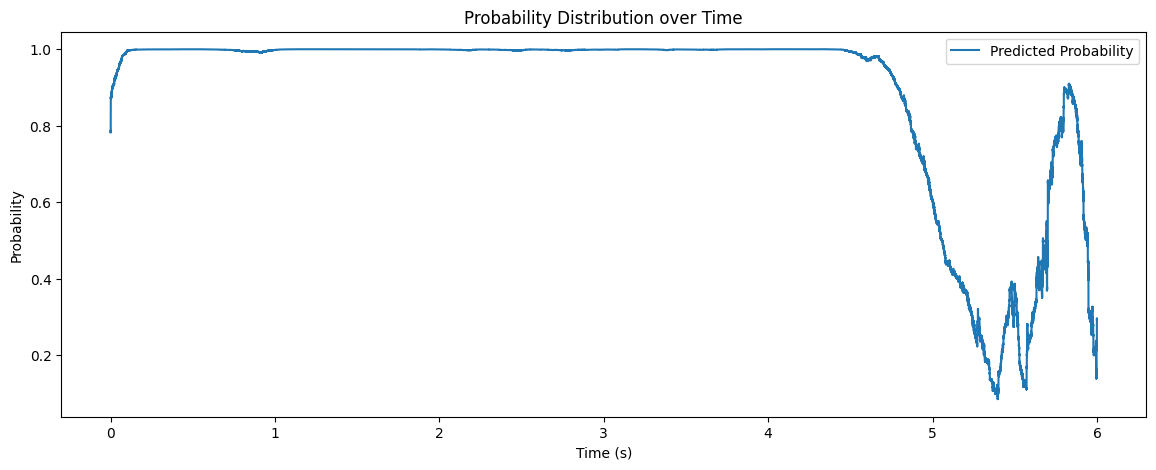

In [323]:
import numpy as np
import matplotlib.pyplot as plt

# Предполагается, что pred = sigmoid(outputs[0]) имеет форму (1, 1, N)
pred_squeezed = np.squeeze(pred)  # получаем массив формы (N,)

# Если исходный сигнал приведён к 6 секундам, то его длительность 6 секунд.
# Либо можно вычислить длительность исходного сигнала: duration = len(signal) / sample_rate
duration = 6.0  # сек.
N = pred_squeezed.shape[0]

# Создаём временную ось: равномерное распределение от 0 до duration с N точками.
time_axis = np.linspace(0, duration, N)

# Отображаем график
plt.figure(figsize=(14, 5))
plt.plot(time_axis, pred_squeezed, label="Predicted Probability")
plt.xlabel("Time (s)")
plt.ylabel("Probability")
plt.title("Probability Distribution over Time")
plt.legend()
plt.show()


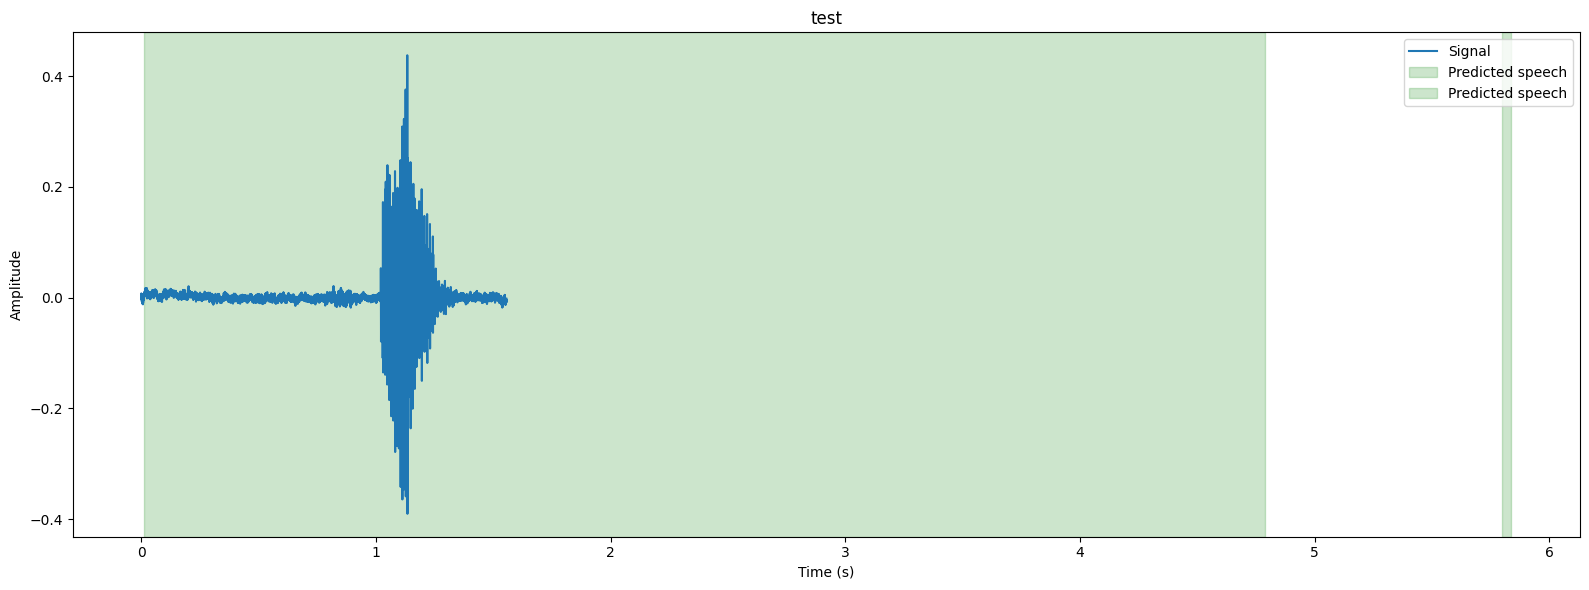

In [325]:
sound_show_numpy(signal, title='test', marks_true=None, marks_pred=pred, threshold=0.9, merge_segments=True, valid_frames=None)

### Example

In [ ]:
num = randint(0, len(data_set_emobase['test_snr_1']))
name, data, marks, signal = data_set_emobase['test_snr_1'][num]
model_emobase.eval()
pred = model_emobase(data.cpu().unsqueeze(0))
pred = torch.round(torch.sigmoid(pred))

sound_show(signal, title=name, marks_true=marks, marks_pred=pred)

In [ ]:
signal